## Notebook 09 - Feature Selection

### Objective
The previous notebooks focused on understanding the acoustic characteristics of the MIMII pump dataset through statistical analysis, signal processing, MFCC analysis, and feature-space visualization.

The objective of this notebook is to identify th emost informative feature subset for anomaly detection before model training.

Unlike dimensionality reduction techniques such as PCA, which maximize overall variance, feature selection aims to retain features that best distinguish normal and abnormal machine behaviour while minimizing redundancy.The selected feature vector produced in this notebook will be used as the input for allsubsequent anomaly detection models.

### Import

In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from src.config import *

In [9]:
overlap_df = pd.read_csv(results_path/"overlap_mfcc_data.csv")
obvious_df = pd.read_csv(results_path/"obvious_mfcc_data.csv")

In [10]:
features = pd.read_csv(results_path/"features.csv")

In [11]:
features["recording_id"] = (features ["label"] + "_" + features["file_name"])
overlap_df["recording_id"] = (overlap_df["label"] + "_" + overlap_df["file_name"])
obvious_df["recording_id"] = (obvious_df["label"] + "_" + obvious_df["file_name"])

In [12]:
overlap_ids = set(overlap_df["recording_id"])
obvious_ids = set(obvious_df["recording_id"])

def assign_research_group(row):
    if row["recording_id"] in overlap_ids:
        return "Overlap"
    elif row["recording_id"] in obvious_ids:
        return "Obvious"
    return "Normal"
features["Research_Group"] = features.apply(assign_research_group, axis=1)

In [14]:
features.to_csv(results_path/"features.csv")

In [15]:
print("=" * 50)
print("Feature Matrix")
print("=" * 50)
print(f"Shape : {features.shape}")

print("\nColumns:\n")
print(features.columns.tolist())


Feature Matrix
Shape : (1149, 54)

Columns:

['file_name', 'label', 'rms', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'centroid_delta', 'centroid_q25', 'centroid_q75', 'centroid_iqr', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'mfcc_14_mean', 'mfcc_14_std', 'mfcc_15_mean', 'mfcc_15_std', 'mfcc_16_mean', 'mfcc_16_std', 'mfcc_17_mean', 'mfcc_17_std', 'mfcc_18_mean', 'mfcc_18_std', 'mfcc_19_mean', 'mfcc_19_std', 'mfcc_20_mean', 'mfcc_20_std', 'Group', 'recording_id', 'Research_Group']


In [16]:
missing = features.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("No missing values found.")
else: display(missing)

No missing values found.


In [18]:
features["Research_Group"].value_counts()

Research_Group
Normal     1006
Obvious      96
Overlap      47
Name: count, dtype: int64

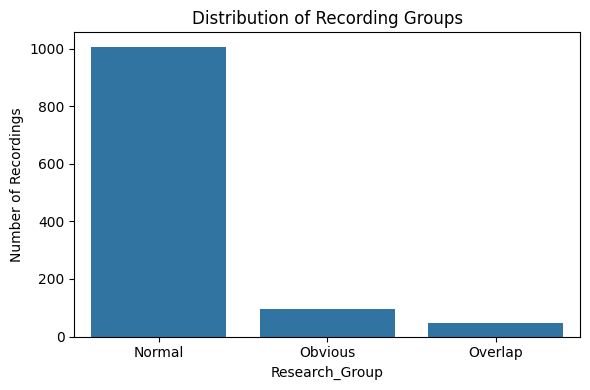

In [20]:
# Class Distribution
plt.figure(figsize = (6, 4))
sns.countplot(data = features, x = "Research_Group")
plt.title("Distribution of Recording Groups")
plt.xlabel("Research_Group")
plt.ylabel("Number of Recordings")
plt.tight_layout()
plt.show()

### Research Evidence

#### Evidence Collected from Previous Notebooks
Feature selection should not rely on a single statistical technique.
Instead, evidence accumulated throughout the exploratory analysis is summarized below and will guide the final feature selection process.

In [21]:
research_evidence = pd.DataFrame({

    "Notebook":[
        "04 RMS Analysis",
        "05 Spectrogram Analysis",
        "06 Spectral Centroid",
        "07 MFCC Analysis",
        "08 Feature Space Analysis"
    ],

    "Key Finding":[

        "RMS overlaps heavily between normal and subtle anomalies.",
        "Subtle anomalies exhibit persistent tonal components while obvious anomalies contain broadband transients.",
        "Centroid variability (Std/IQR) is more discriminative than centroid mean.",
        "MFCC-1, MFCC-2 and their variability provide the strongest separation. Higher-order MFCCs contribute little.",
        "PCA variance differs from anomaly discrimination; normal behaviour is multimodal."
    ],

    "Impact on Feature Selection":[
        "Do not rely on RMS as the primary descriptor.",
        "Need spectral features capable of capturing tonal changes.",
        "Retain centroid variability measures.",
        "Prioritize low-order MFCC statistics.",
        "Use supervised feature selection rather than PCA alone."
    ]
})

research_evidence

,Notebook,Key Finding,Impact on Feature Selection
0,04 RMS Analysis,RMS overlaps heavily between normal and subtle...,Do not rely on RMS as the primary descriptor.
1,05 Spectrogram Analysis,Subtle anomalies exhibit persistent tonal comp...,Need spectral features capable of capturing to...
2,06 Spectral Centroid,Centroid variability (Std/IQR) is more discrim...,Retain centroid variability measures.
3,07 MFCC Analysis,"MFCC-1, MFCC-2 and their variability provide t...",Prioritize low-order MFCC statistics.
4,08 Feature Space Analysis,PCA variance differs from anomaly discriminati...,Use supervised feature selection rather than P...


In [22]:
research_evidence.to_csv(results_path/"research_evidence.csv", index = False)

### Label Encoding

Although the final anomaly detection models will be trained only on normal recordings, supervised feature selection requires class labels in order in order to estimate the discriminative power of each engineered feature.

The labels used here are therefore intended solely for feature evaluation and will not be used during unsupervised model training.

In [23]:
encoder = LabelEncoder()
features["Label"] = encoder.fit_transform(features["Research_Group"])
features[["Research_Group", "Label"]].drop_duplicates()

,Research_Group,Label
0,Normal,0
1006,Obvious,1
1098,Overlap,2


In [31]:
feature_columns = [
    col for col in features.columns
    if col not in ["file_name", "label", "Group", "Research_Group", "Label", "recording_id"]]
x = features[feature_columns]
y = features["Label"]
print(f"Feature matrix shape: {x.shape}")
print(f"Target shape : {y.shape}")

Feature matrix shape: (1149, 49)
Target shape : (1149,)


### Candidate Features

In [32]:
candidate_features = pd.DataFrame({
    "Feature": feature_columns,
    "Slected": False,
    "Reason": ""
})
candidate_features.head()

,Feature,Slected,Reason
0,rms,False,
1,centroid_mean,False,
2,centroid_std,False,
3,centroid_min,False,
4,centroid_max,False,


# Part 2: Statistical Feature Ranking

## Objective
The purpose of this section is to evaluate each engineered feature based on its ability to distinguish between the three research groups:
- Normal
- Overlap
- Obvious

Two complementary feature selection methods are used:
1. **ANOVA F-Score**
   - Measures how well feature means differ across groups.
   - Higher scores indicate stronger linear discrimination.
2. **Mutual Information**
   - Measures both linear and nonlinear dependence between features and class      labels.
   - Captures relationships that ANOVA may overlook.
    
The results from both methods will later be combined with findings from previous notebooks and model-based feature importance to construct the final feature vector.

In [27]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif

In [33]:
print(f"Number of recordings : {len(features)}")
print(f"Number of features : {len(feature_columns)}")
print("\nGroups")
display(features["Research_Group"].value_counts())

Number of recordings : 1149
Number of features : 49

Groups


Research_Group
Normal     1006
Obvious      96
Overlap      47
Name: count, dtype: int64

### ANOVA Feature Ranking

In [41]:
f_scores, p_values = f_classif(x, y)
anova_results = pd.DataFrame({
    "Feature": feature_columns,
    "F_score": f_scores,
    "p_value": p_values,
})
anova_results = (anova_results
    .sort_values("F_score", ascending = False)
    .reset_index(drop = True)
                )
anova_results.head(15)

,Feature,F_score,p_value
0,rms,2849.198722,0.000000e+00
1,mfcc_1_mean,848.686112,7.346261e-227
2,mfcc_6_mean,224.094919,7.200206e-83
3,mfcc_5_mean,223.667985,9.787419e-83
4,mfcc_8_mean,212.421614,3.378050e-79
5,mfcc_5_std,202.172317,6.271889e-76
6,mfcc_9_mean,181.878473,2.506421e-69
7,mfcc_2_std,160.792400,2.812869e-62
8,mfcc_6_std,138.546514,1.288577e-54
9,mfcc_7_mean,115.919168,1.419648e-46


In [37]:
anova_results.to_csv(results_path/"anova_feature_scores.csv", index = False)

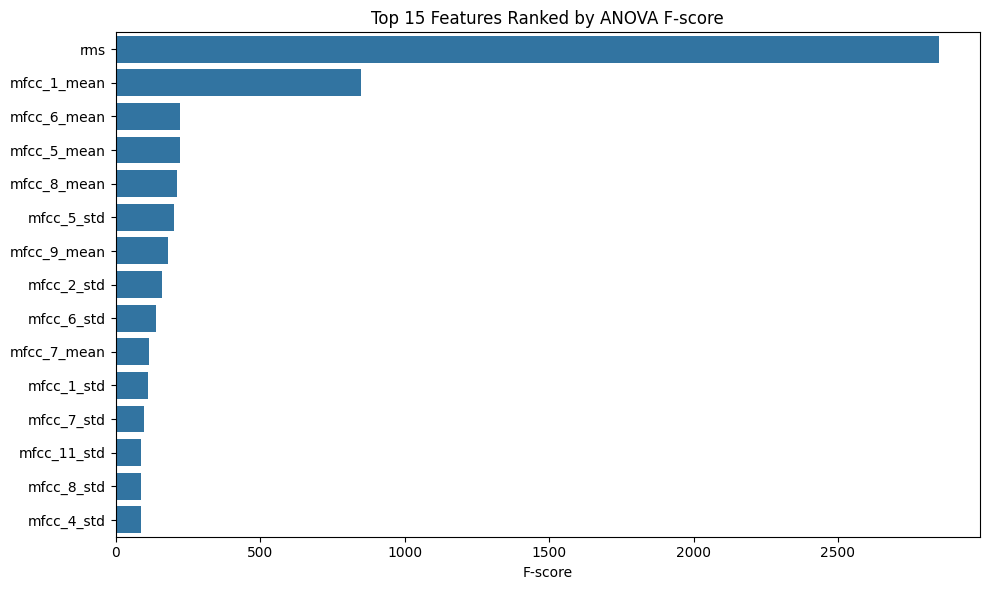

In [38]:
plt.figure(figsize = (10, 6))
sns.barplot(data = anova_results.head(15),
            x = "F_score", y = "Feature")
plt.title("Top 15 Features Ranked by ANOVA F-score")
plt.xlabel("F-score")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [39]:
significant = anova_results[ anova_results["p_value"] < 0.05]
print(f"Statistically significant features : {len(significant)}")

Statistically significant features : 45


### Mutual Information

In [43]:
mi_scores = mutual_info_classif(x, y, random_state = 42)
mi_results = pd.DataFrame({
    "Feature": feature_columns,
    "MI_score": mi_scores})
mi_results = (mi_results
    .sort_values("MI_score", ascending = False)
    .reset_index(drop = True))

mi_results.head(15)

,Feature,MI_score
0,rms,0.391083
1,mfcc_1_mean,0.336490
2,mfcc_5_std,0.205146
3,mfcc_2_std,0.179685
4,mfcc_1_std,0.171810
5,mfcc_8_mean,0.146793
6,centroid_std,0.144720
7,mfcc_6_mean,0.138977
8,centroid_iqr,0.130407
9,mfcc_9_mean,0.129627


In [44]:
mi_results.to_csv(results_path/"mutual_information_scores.csv", index = False)

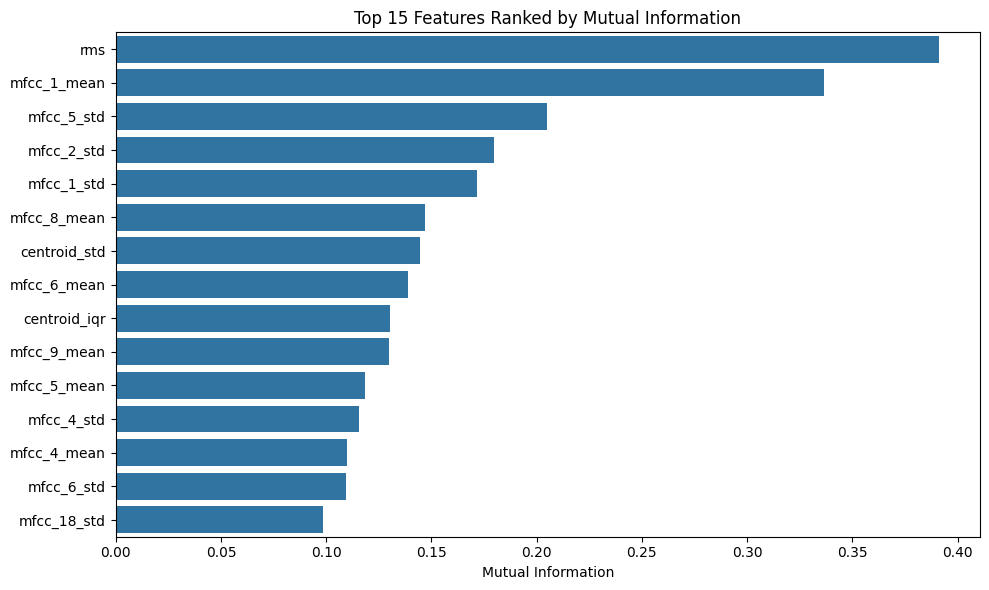

In [46]:
plt.figure(figsize = (10, 6))
sns.barplot(data = mi_results.head(15),
            x = "MI_score", y = "Feature")
plt.title("Top 15 Features Ranked by Mutual Information")
plt.xlabel("Mutual Information")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Comparison of Rnakings

In [47]:
comparison = (anova_results[["Feature", "F_score"]]
              .merge(mi_results[["Feature", "MI_score"]],
                     on = "Feature"))

comparison.head()

,Feature,F_score,MI_score
0,rms,2849.198722,0.391083
1,mfcc_1_mean,848.686112,0.336490
2,mfcc_6_mean,224.094919,0.138977
3,mfcc_5_mean,223.667985,0.118412
4,mfcc_8_mean,212.421614,0.146793


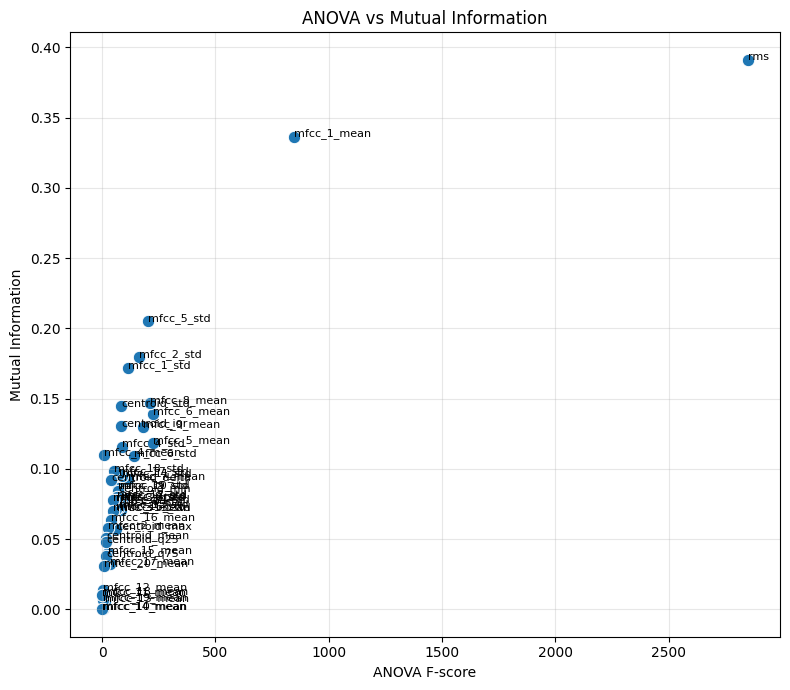

In [84]:
plt.figure(figsize = (8, 7))
sns.scatterplot(data = comparison,
                x= "F_score", y = "MI_score", s = 80)
for _, row in comparison.iterrows():
    plt.text(row["F_score"], row["MI_score"], row["Feature"], fontsize = 8)

plt.title("ANOVA vs Mutual Information")
plt.xlabel("ANOVA F-score")
plt.ylabel("Mutual Information")
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.savefig(results_path /"figures"/"feature_selection"/
            "anova_vs_mi.png",
    dpi=300
)
plt.show()

### Top Features by both methods

In [52]:
comparison["ANOVA Rank"] = comparison["F_score"].rank(
    ascending = False, method = "min")

comparison["MI Rank"] = comparison["MI_score"].rank(
    ascending = False, method = "min")

comparison["Average Rank"] = (comparison["ANOVA Rank"]+ comparison["MI Rank"]
) / 2

comparison = comparison.sort_values("Average Rank")

comparison.head(15)

,Feature,F_score,MI_score,ANOVA Rank,MI Rank,Average Rank
0,rms,2849.198722,0.391083,1.0,1.0,1.0
1,mfcc_1_mean,848.686112,0.336490,2.0,2.0,2.0
5,mfcc_5_std,202.172317,0.205146,6.0,3.0,4.5
2,mfcc_6_mean,224.094919,0.138977,3.0,8.0,5.5
4,mfcc_8_mean,212.421614,0.146793,5.0,6.0,5.5
7,mfcc_2_std,160.792400,0.179685,8.0,4.0,6.0
3,mfcc_5_mean,223.667985,0.118412,4.0,11.0,7.5
10,mfcc_1_std,113.129249,0.171810,11.0,5.0,8.0
6,mfcc_9_mean,181.878473,0.129627,7.0,10.0,8.5
8,mfcc_6_std,138.546514,0.109183,9.0,14.0,11.5


## Observation - Summary

Statistical feature ranking using ANOVA F-score and Mutual Information revealed several important characteristics of the engineered feature space.

The two methods showed strong agreement in identifying **RMS** and **mfcc_1_mean** as the most informative individual features. Their consistently high rankings under both linear (ANOVA) and non-linear (Mutual Information) criteria provide strong evidence that overall signal energy and the first cepstral coefficient play a central role in distinguishing machine operating conditions.

The analysis also highlighted an important distinction between different types of informative features. While several MFCC mean features (particularly mfcc_5_mean, mfcc_6_mean, mfcc_8_mean and mfcc_9_mean) ranked highly under ANOVA due to clear mean-level differences between groups, variability-based features such as **mfcc_1_std, mfcc_2_std, centroid_std and centroid_iqr** received substantially higher rankings under Mutual Information. This suggests that these features contain non-linear discriminative information that is not fully captured by linear statistical tests.

Interestingly, the results differ from the PCA analysis performed in Notebook 08. Spectral centroid features, which dominated the principal components, did not rank among the strongest ANOVA features. This reinforces the earlier conclusion that **features explaining the greatest overall dataset variance are not necessarily the features that best discriminate anomalous machine behaviour.**

Overall, the statistical ranking confirms that no single feature family is sufficient on its own. Instead, the most promising feature set appears to combine complementary information from **energy (RMS), low-order MFCC statistics, MFCC variability, and spectral centroid variability**. These findings provide the statistical foundation for the final feature selection process in the next section, where statistical rankings will be combined with previous signal processing evidence and model-based feature importance to construct the final feature vector for anomaly detection.

# Part 3 - Evidence-Based Feature Selection


## Objective
The previous section ranked the engineered features using statistical methods (ANOVA and Mutual Information). While these methods quantify feature relevance individually, they do not account for interactions between features.

This section introduces a model-based feature ranking using Random Forests, by an evidence-based feature selection strategy that combines:
- Signal Processing Observations
- Statistical ranking (ANOVA)
- Information-theoretic ranking (Mutual Information)
- Model-based importance (Random Forest)

In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
rf = RandomForestClassifier(
    n_estimators = 500, random_state = 42, class_weight = "balanced"
)
rf.fit(x, y)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

In [57]:
rf_results = pd.DataFrame({
    "Feature": feature_columns,
    "RF Importance": rf.feature_importances_
})

rf_results = rf_results.sort_values("RF Importance", ascending = False).reset_index(drop = True)

rf_results.head(15)

,Feature,RF Importance
0,rms,0.194591
1,mfcc_1_mean,0.157145
2,mfcc_6_std,0.051047
3,mfcc_5_std,0.049146
4,mfcc_8_mean,0.044945
5,mfcc_2_std,0.037499
6,mfcc_9_mean,0.034930
7,mfcc_1_std,0.034162
8,mfcc_8_std,0.029619
9,mfcc_6_mean,0.025207


In [58]:
rf_results.to_csv(results_path/"random_forest_importance.csv", index = False)

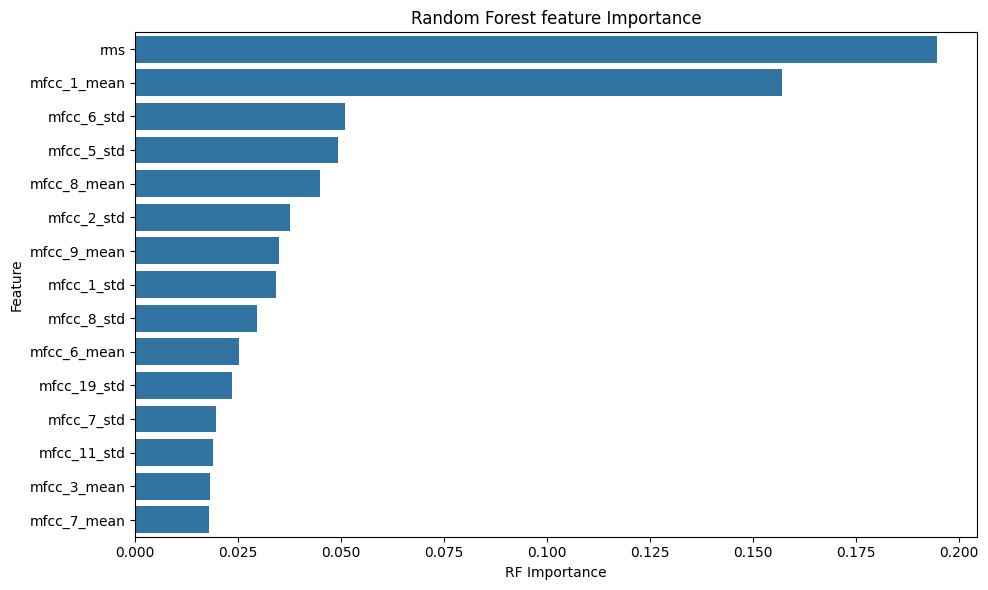

In [59]:
plt.figure(figsize = (10, 6))
sns.barplot(data = rf_results.head(15),
            x = "RF Importance", y = "Feature")
plt.title("Random Forest feature Importance")
plt.tight_layout()
plt.show()

In [60]:
ranking = comparison.merge(rf_results, on = "Feature")

In [63]:
ranking["RF Rank"] = ranking["RF Importance"].rank(
    ascending = False, method = "min")

In [66]:
evidence = pd.DataFrame({"Feature": ranking["Feature"]})

### Signal Analysis

In [67]:
signal_processing = {
    "rms",
    "centroid_std",
    "centroid_iqr",
    "mfcc_1_mean",
    "mfcc_1_std",
    "mfcc_2_mean",
    "mfcc_2_std",
    "mfcc_3_mean"
}

### Notebook 08 discoveries

In [68]:
feature_space = {
    "centroid_std",
    "centroid_iqr",
    "mfcc_1_mean",
    "mfcc_2_mean",
    "mfcc_8_mean"
}

### Top features from ANOVA, MI and RF

In [69]:
top10_anova = set(anova_results.head(10)["Feature"])
top10_mi = set(mi_results.head(10)["Feature"])
top10_rf = set(rf_results.head(10)["Feature"])

In [70]:
evidence["Signal"] = evidence["Feature"].isin(
    signal_processing
).astype(int)

evidence["Feature Space"] = evidence["Feature"].isin(
    feature_space
).astype(int)

evidence["ANOVA"] = evidence["Feature"].isin(
    top10_anova
).astype(int)

evidence["MI"] = evidence["Feature"].isin(
    top10_mi
).astype(int)

evidence["RF"] = evidence["Feature"].isin(
    top10_rf
).astype(int)

In [71]:
evidence["Evidence Score"] = (
    evidence["Signal"]
    +
    evidence["Feature Space"]
    +
    evidence["ANOVA"]
    +
    evidence["MI"]
    +
    evidence["RF"]
)

evidence = evidence.sort_values("Evidence Score", ascending=False)
evidence.head(20)

,Feature,Signal,Feature Space,ANOVA,MI,RF,Evidence Score
1,mfcc_1_mean,1,1,1,1,1,5
0,rms,1,0,1,1,1,4
4,mfcc_8_mean,0,1,1,1,1,4
5,mfcc_2_std,1,0,1,1,1,4
7,mfcc_1_std,1,0,0,1,1,3
11,centroid_iqr,1,1,0,1,0,3
8,mfcc_9_mean,0,0,1,1,1,3
10,centroid_std,1,1,0,1,0,3
3,mfcc_6_mean,0,0,1,1,1,3
2,mfcc_5_std,0,0,1,1,1,3


In [72]:
evidence.to_csv(results_path/ "feature_evidence_matrix.csv",index=False)

In [77]:
results_path.mkdir(exist_ok = True)
(results_path/"figures"/"feature_selection").mkdir(exist_ok = True)

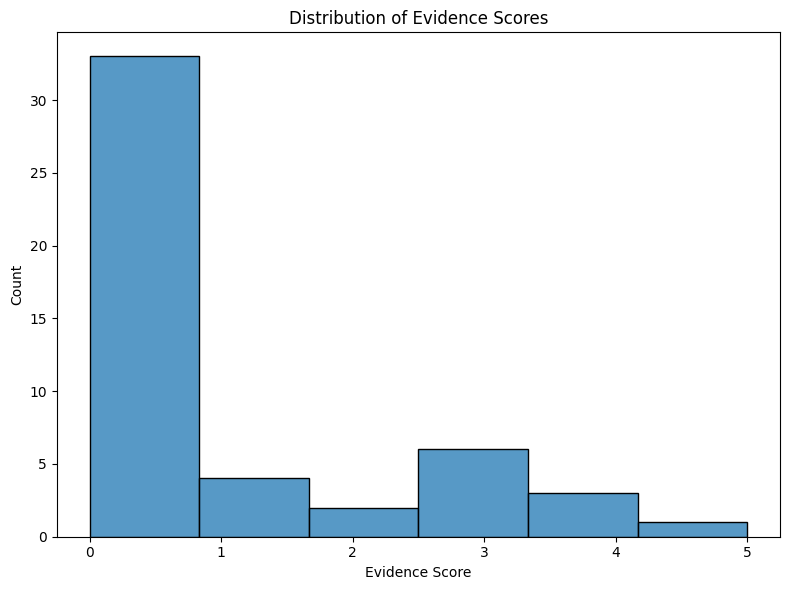

In [78]:
plt.figure(figsize=(8,6))
sns.histplot(evidence["Evidence Score"], bins=6)
plt.title("Distribution of Evidence Scores")
plt.tight_layout()
plt.savefig(results_path /"figures"/"feature_selection"/
            "evidence_distribution.png",
    dpi=300
)

plt.show()

In [88]:
display(evidence.head(20))

,Feature,Signal,Feature Space,ANOVA,MI,RF,Evidence Score
1,mfcc_1_mean,1,1,1,1,1,5
0,rms,1,0,1,1,1,4
4,mfcc_8_mean,0,1,1,1,1,4
5,mfcc_2_std,1,0,1,1,1,4
7,mfcc_1_std,1,0,0,1,1,3
11,centroid_iqr,1,1,0,1,0,3
8,mfcc_9_mean,0,0,1,1,1,3
10,centroid_std,1,1,0,1,0,3
3,mfcc_6_mean,0,0,1,1,1,3
2,mfcc_5_std,0,0,1,1,1,3


### Selected features

In [80]:
selected_features = [
    "rms",
    "mfcc_1_mean",
    "mfcc_1_std",
    "mfcc_2_mean",
    "mfcc_2_std",
    "mfcc_5_std",
    "mfcc_8_mean",
    "centroid_std",
    "centroid_iqr"
]

In [81]:
selected_dataset = features[
    ["file_name", "label", "Research_Group"]
    +
    selected_features
    ]

In [82]:
selected_dataset.to_csv(results_path/"selected_features.csv", index = False)

### Final Outcome

Feature selection combined domain knowledge from signal processing with three independent statistical methods (ANOVA, Mutual Information and Random Forest importance). Rather than relying on a single ranking criterion, the final feature vector was selected by intergrating statistical evidence with insights from earlier exploratory analyses. This produced a compact set of nine complementary features capturing signal energy (RMS), spectral envelpe characteristics (MFCCs), and spectral distribution dynamics (Spectral Centroid), providing an interpretable feature representation for subsequent anomaly detection models.